# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project 1: Market Basket analysis

## Learning Objectives

At the end of the experiment, you will be able to:

* extract summary level insight from a given dataset

* Integrate the data and identify the underlying pattern or structure

* understand the fundamentals of market basket analysis

* construct "rules" that provide concrete recommendations for businesses

## Dataset

The dataset chosen for this mini project is **Instacart Dataset**. The dataset is anonymized and contains a sample of over 3 million grocery orders from more than 200,000 Instacart users. For each user, there are orders between 4 and 100, with the sequence of products purchased in each order. The dataset also includes the products in each order, the time of day and day of week of each order, the name and aisle/department of each product, which are stored across various files.

## Problem Statement


Extract association rules and find groups of frequently purchased items from a large-scale grocery orders dataset.

## Grading = 10 Points

#### Import required packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


## **Stage 1**: Data Wrangling

We have five different files:

    - orders.csv
    - order_products__train.csv
    - products.csv
    - aisles.csv
    - departments.csv

These files contain the neccesary data to solve the problem. Load all the files correctly, after observing the header level details, data records etc

**Hint:** Use `read_csv` from pandas

In [2]:
# @title Download the data
# !wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/Instacart.zip
# !unzip -qq Instacart.zip

from utility import download_and_unzip

download_and_unzip(
    filename="Instacart.zip",
    url="https://cdn.iisc.talentsprint.com/CDS/Datasets/Instacart.zip",
)

print("Data downloaded successfully")


Data downloaded successfully


### Load the data

Load all the given datasets

In [3]:
def showBasicInfo(dataframes, aspect="all"):
    for df in dataframes:
        if aspect.__eq__("columns") | aspect.__eq__("column"):
            print(f"{df[0]} columns are: {df[1].columns.tolist()}")
        elif aspect.__eq__("shape") | aspect.__eq__("shapes"):
            print(f"{df[0]} shape is: {df[1].shape}")
        elif aspect.__eq__("dtypes") | aspect.__eq__("data types"):
            print(f"{df[0]} data types are: {df[1].dtypes}")
        elif aspect.__eq__("missing") | aspect.__eq__("missing values"):
            print(f"{df[0]} missing values are: {df[1].isnull().sum()}")
        elif aspect.__eq__("head") | aspect.__eq__("first 5 rows"):
            print(f"{df[0]} first 5 rows are:\n{df[1].head()}")
        elif aspect.__eq__("describe") | aspect.__eq__("descriptive statistics"):
            print(f"{df[0]} descriptive statistics are:\n{df[1].describe()}")
        else:
            print("\n\nShape: ", df[1].shape)
            print("\n\nColumns: ", df[1].columns)
            print("\n\nData Types: ", df[1].dtypes)
            print("\n\nMissing Values: ", df[1].isnull().sum())
            dict_no_of_unique_values = {}
            for col in df[1].columns:
                dict_no_of_unique_values[col] = df[1][col].nunique()
            print("\n\nNumber of Unique Values: ", dict_no_of_unique_values)
            print("\n\nFirst 5 Rows:\n", df[1].head())
            print("\n\nDescriptive Statistics:\n", df[1].describe())
            print("\n\n")


In [4]:
# YOUR CODE HERE
orders = pd.read_csv("Instacart/orders.csv")
showBasicInfo([["orders", orders]])




Shape:  (3421083, 7)


Columns:  Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')


Data Types:  order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object


Missing Values:  order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64


Number of Unique Values:  {'order_id': 3421083, 'user_id': 206209, 'eval_set': 3, 'order_number': 100, 'order_dow': 7, 'order_hour_of_day': 24, 'days_since_prior_order': 31}


First 5 Rows:
    order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329      

In [5]:
order_products = pd.read_csv("Instacart/order_products__train.csv")
showBasicInfo([["order_products", order_products]])




Shape:  (1384617, 4)


Columns:  Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')


Data Types:  order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object


Missing Values:  order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


Number of Unique Values:  {'order_id': 131209, 'product_id': 39123, 'add_to_cart_order': 80, 'reordered': 2}


First 5 Rows:
    order_id  product_id  add_to_cart_order  reordered
0         1       49302                  1          1
1         1       11109                  2          1
2         1       10246                  3          0
3         1       49683                  4          0
4         1       43633                  5          1


Descriptive Statistics:
            order_id    product_id  add_to_cart_order     reordered
count  1.384617e+06  1.384617e+06       1.384617e+06  1.384617e+06
mean   

In [6]:
products = pd.read_csv("Instacart/products.csv")
showBasicInfo([["products", products]])




Shape:  (49688, 4)


Columns:  Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object')


Data Types:  product_id        int64
product_name     object
aisle_id          int64
department_id     int64
dtype: object


Missing Values:  product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64


Number of Unique Values:  {'product_id': 49688, 'product_name': 49688, 'aisle_id': 134, 'department_id': 21}


First 5 Rows:
    product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13

In [7]:
departments = pd.read_csv("Instacart/departments.csv")
showBasicInfo([["departments", departments]])




Shape:  (21, 2)


Columns:  Index(['department_id', 'department'], dtype='object')


Data Types:  department_id     int64
department       object
dtype: object


Missing Values:  department_id    0
department       0
dtype: int64


Number of Unique Values:  {'department_id': 21, 'department': 21}


First 5 Rows:
    department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


Descriptive Statistics:
        department_id
count      21.000000
mean       11.000000
std         6.204837
min         1.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        21.000000





In [8]:
aisles = pd.read_csv("Instacart/aisles.csv")
showBasicInfo([["aisles", aisles]])




Shape:  (134, 2)


Columns:  Index(['aisle_id', 'aisle'], dtype='object')


Data Types:  aisle_id     int64
aisle       object
dtype: object


Missing Values:  aisle_id    0
aisle       0
dtype: int64


Number of Unique Values:  {'aisle_id': 134, 'aisle': 134}


First 5 Rows:
    aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


Descriptive Statistics:
          aisle_id
count  134.000000
mean    67.500000
std     38.826537
min      1.000000
25%     34.250000
50%     67.500000
75%    100.750000
max    134.000000





### Data Integration (1 point)

As the required data is present in different files, we need to integrate all the five to make single dataframe/dataset. For that purpose, use the unique identifier provided in all the dataframes so that it can be used to map the data in different files correctly.

**Example:** `product_id` is available in both `products` dataframe and `order_products__train` dataframe, we can merge these two into a single dataframe based on `product_id`

**Hint:** [pd.merge](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)

In [9]:
showBasicInfo(
    dataframes=[
        ["orders", orders],
        ["order_products", order_products],
        ["products", products],
        ["aisles", aisles],
        ["departments", departments],
    ],
    aspect="columns",
)


orders columns are: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
order_products columns are: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']
products columns are: ['product_id', 'product_name', 'aisle_id', 'department_id']
aisles columns are: ['aisle_id', 'aisle']
departments columns are: ['department_id', 'department']


In [10]:
showBasicInfo(
    dataframes=[
        ["orders", orders],
        ["order_products", order_products],
        ["products", products],
        ["aisles", aisles],
        ["departments", departments],
    ],
    aspect="shape",
)


orders shape is: (3421083, 7)
order_products shape is: (1384617, 4)
products shape is: (49688, 4)
aisles shape is: (134, 2)
departments shape is: (21, 2)


In [11]:
# YOUR CODE HERE

product_aisle_department = pd.merge(products, aisles, on="aisle_id", how="inner").merge(
    departments, on="department_id", how="inner"
)
showBasicInfo(
    dataframes=[["product_aisle_department", product_aisle_department]],
    aspect="shape",
)
product_aisle_department.head()


product_aisle_department shape is: (49688, 6)


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [12]:
order_product_denormalized = pd.merge(
    order_products, product_aisle_department, on="product_id", how="inner"
)
showBasicInfo(
    dataframes=[["order_product_denormalized", order_product_denormalized]],
    aspect="shape",
)
order_product_denormalized.head()


order_product_denormalized shape is: (1384617, 9)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [13]:
orders_denormalized = pd.merge(
    order_product_denormalized, orders, on="order_id", how="inner"
)
showBasicInfo(
    dataframes=[["orders_denormalized", orders_denormalized]],
    aspect="shape",
)
orders_denormalized.head()


orders_denormalized shape is: (1384617, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1,49302,1,1,Bulgarian Yogurt,120,16,yogurt,dairy eggs,112108,train,4,4,10,9.0
1,1,11109,2,1,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs,112108,train,4,4,10,9.0
2,1,10246,3,0,Organic Celery Hearts,83,4,fresh vegetables,produce,112108,train,4,4,10,9.0
3,1,49683,4,0,Cucumber Kirby,83,4,fresh vegetables,produce,112108,train,4,4,10,9.0
4,1,43633,5,1,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods,112108,train,4,4,10,9.0


In [14]:
# TODO check why the number of rows is not same as orders


### Understanding relationships and new insights from the data (3 points)

1.  How many times was each product ordered?

    **Hint:** group orders by product
    

2.  Find the number of orders per department and visualize using an appropriate plot


3.  On which day of the week do customers tend to buy more groceries? Which are the peak hours
of shopping?

  * Find the frequency of orders on week days using an appropriate plot
  * Find the frequency of orders during hours of the day using an appropriate plot?
  

4. Find the ratio of Re-ordered and Not Re-ordered products and visualize it

5. Plot the heatmap of Re-order ratio of the Day of week vs Hour of day

In [15]:
# YOUR CODE HERE
# Group by 'product_id' and 'product_name', then count the number of times each product was ordered
product_order_counts = (
    orders_denormalized.groupby(["product_id", "product_name"])["order_id"]
    .count()
    .reset_index(name="order_count")
)

# Display the top 10 most ordered products
product_order_counts.sort_values("order_count", ascending=False).head(10)


,product_id,product_name,order_count
19574,24852,Banana,18726
10367,13176,Bag of Organic Bananas,15480
16685,21137,Organic Strawberries,10894
17300,21903,Organic Baby Spinach,9784
37499,47626,Large Lemon,8135
37609,47766,Organic Avocado,7409
37164,47209,Organic Hass Avocado,7293
13228,16797,Strawberries,6494
20648,26209,Limes,6033
22024,27966,Organic Raspberries,5546


In [16]:
product_order_counts = orders_denormalized["product_name"].value_counts().reset_index()
product_order_counts.columns = ["product_name", "order_count"]
print("Top 10 most ordered products:")
print(product_order_counts.head(10))


Top 10 most ordered products:
             product_name  order_count
0                  Banana        18726
1  Bag of Organic Bananas        15480
2    Organic Strawberries        10894
3    Organic Baby Spinach         9784
4             Large Lemon         8135
5         Organic Avocado         7409
6    Organic Hass Avocado         7293
7            Strawberries         6494
8                   Limes         6033
9     Organic Raspberries         5546


In [17]:
print("\n--- Department Order Counts ---")
department_order_counts = orders_denormalized["department"].value_counts().reset_index()
department_order_counts.columns = ["department", "order_count"]
print("Number of orders per department:")
print(department_order_counts)



--- Department Order Counts ---
Number of orders per department:
         department  order_count
0           produce       409087
1        dairy eggs       217051
2            snacks       118862
3         beverages       114046
4            frozen       100426
5            pantry        81242
6            bakery        48394
7      canned goods        46799
8              deli        44291
9   dry goods pasta        38713
10        household        35986
11     meat seafood        30307
12        breakfast        29500
13    personal care        21570
14           babies        14941
15    international        11902
16          missing         8251
17          alcohol         5598
18             pets         4497
19            other         1795
20             bulk         1359


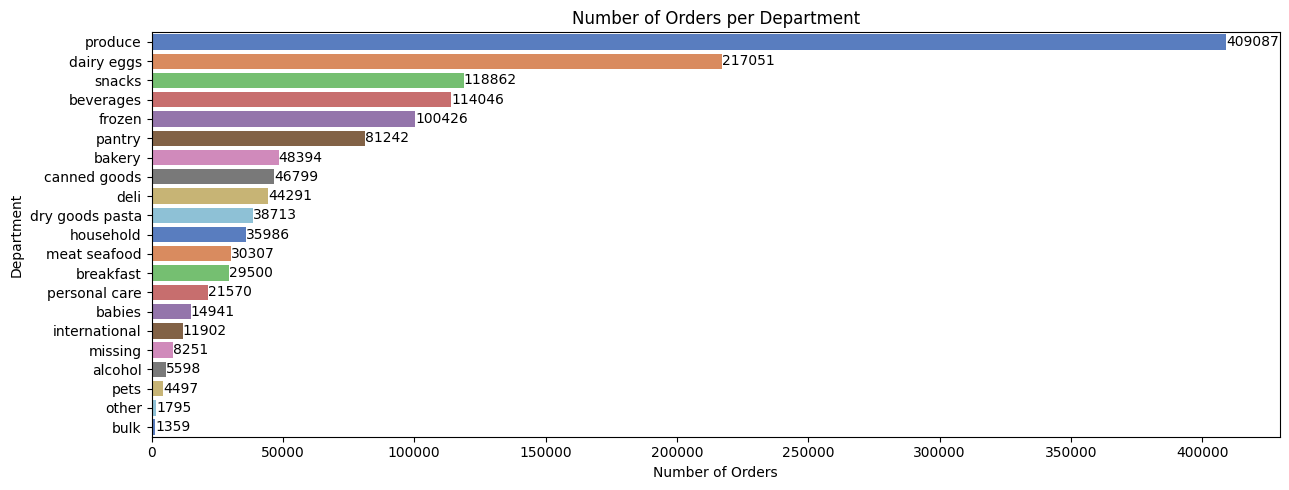

In [18]:
plt.figure(figsize=(13, 5))
ax = sns.barplot(
    x="order_count",
    y="department",
    data=department_order_counts.sort_values(by="order_count", ascending=False),
    palette="muted",
    # hue=department_order_counts["department"],
    hue="department",
    legend=None,
)
plt.title("Number of Orders per Department")
plt.xlabel("Number of Orders")
plt.ylabel("Department")
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()



--- Orders by Day of Week ---


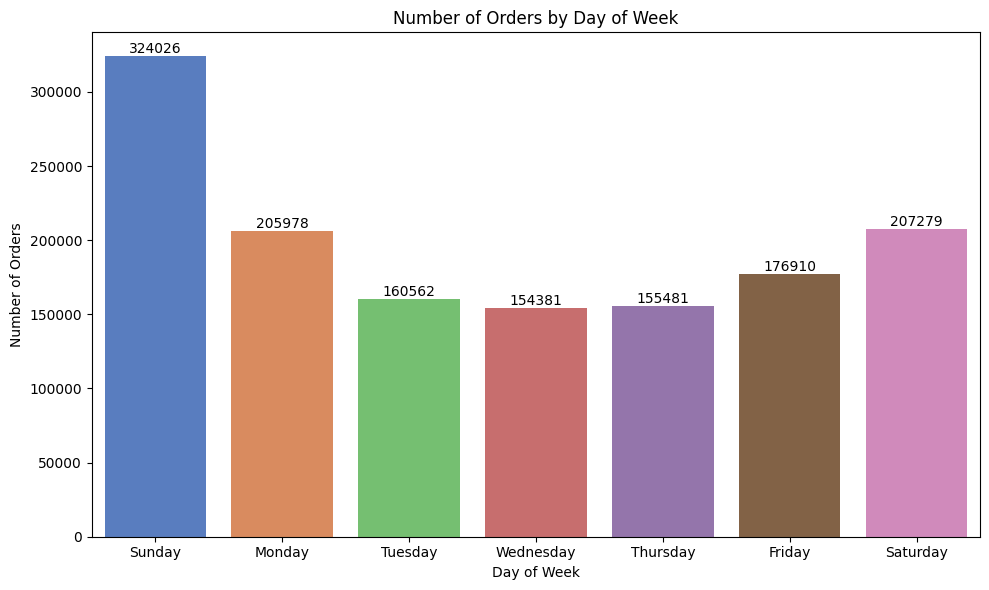

In [19]:
print("\n--- Orders by Day of Week ---")
orders_dow = orders_denormalized["order_dow"].value_counts().sort_index()
# Map day of week to names for better readability in plot
dow_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
}
orders_dow_mapped = orders_dow.rename(index=dow_map)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=orders_dow_mapped.index,
    y=orders_dow_mapped.values,
    palette="muted",
    hue=orders_dow_mapped.index,
    legend=False,
)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.tight_layout()
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()



--- Orders by Hour of Day ---


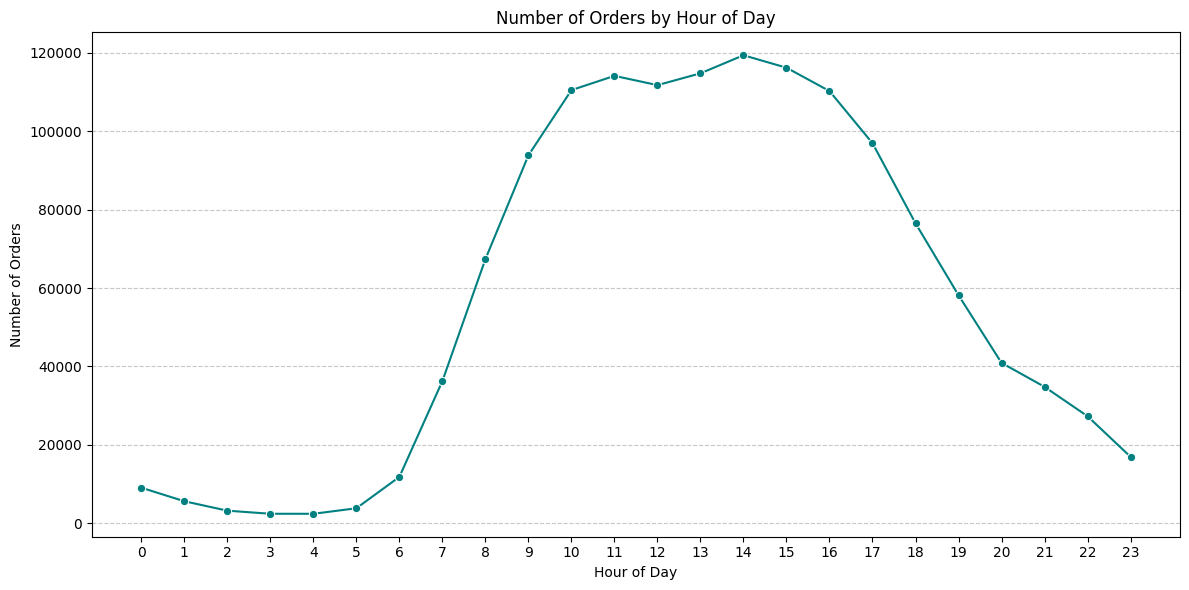

In [20]:
print("\n--- Orders by Hour of Day ---")
orders_hour_of_day = (
    orders_denormalized["order_hour_of_day"].value_counts().sort_index()
)
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    x=orders_hour_of_day.index, y=orders_hour_of_day.values, marker="o", color="teal"
)
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()



--- Re-ordered vs. Not Re-ordered Products ---
Re-ordered products: 828824
Not re-ordered products: 555793
Re-order ratio (Re-ordered / Total): 0.60


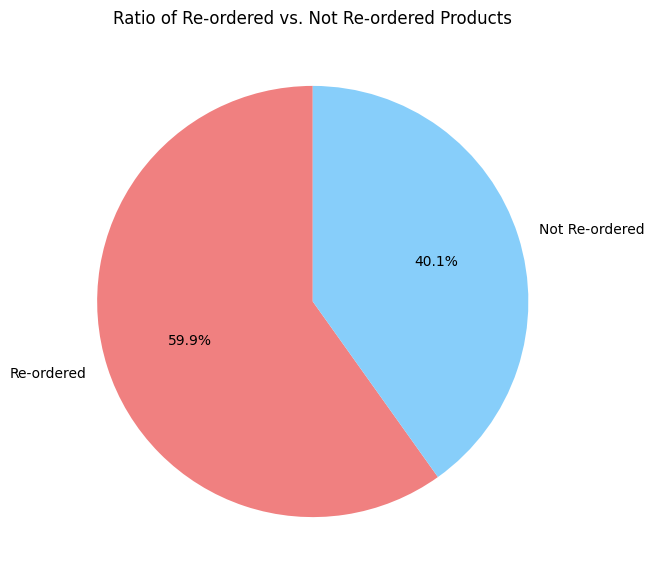

In [21]:
print("\n--- Re-ordered vs. Not Re-ordered Products ---")
reorder_counts = orders_denormalized["reordered"].value_counts()
if 0 in reorder_counts and 1 in reorder_counts:
    reorder_ratio = reorder_counts[1] / (reorder_counts[0] + reorder_counts[1])
    print(f"Re-ordered products: {reorder_counts[1]}")
    print(f"Not re-ordered products: {reorder_counts[0]}")
    print(f"Re-order ratio (Re-ordered / Total): {reorder_ratio:.2f}")

    plt.figure(figsize=(7, 7))
    plt.pie(
        reorder_counts,
        labels=["Re-ordered", "Not Re-ordered"],
        autopct="%1.1f%%",
        colors=["lightcoral", "lightskyblue"],
        startangle=90,
    )
    plt.title("Ratio of Re-ordered vs. Not Re-ordered Products")
    plt.show()
else:
    print(
        "Cannot calculate re-order ratio as one of the categories (re-ordered/not re-ordered) is missing."
    )



--- Heatmap of Re-order Ratio by Day of Week and Hour of Day ---


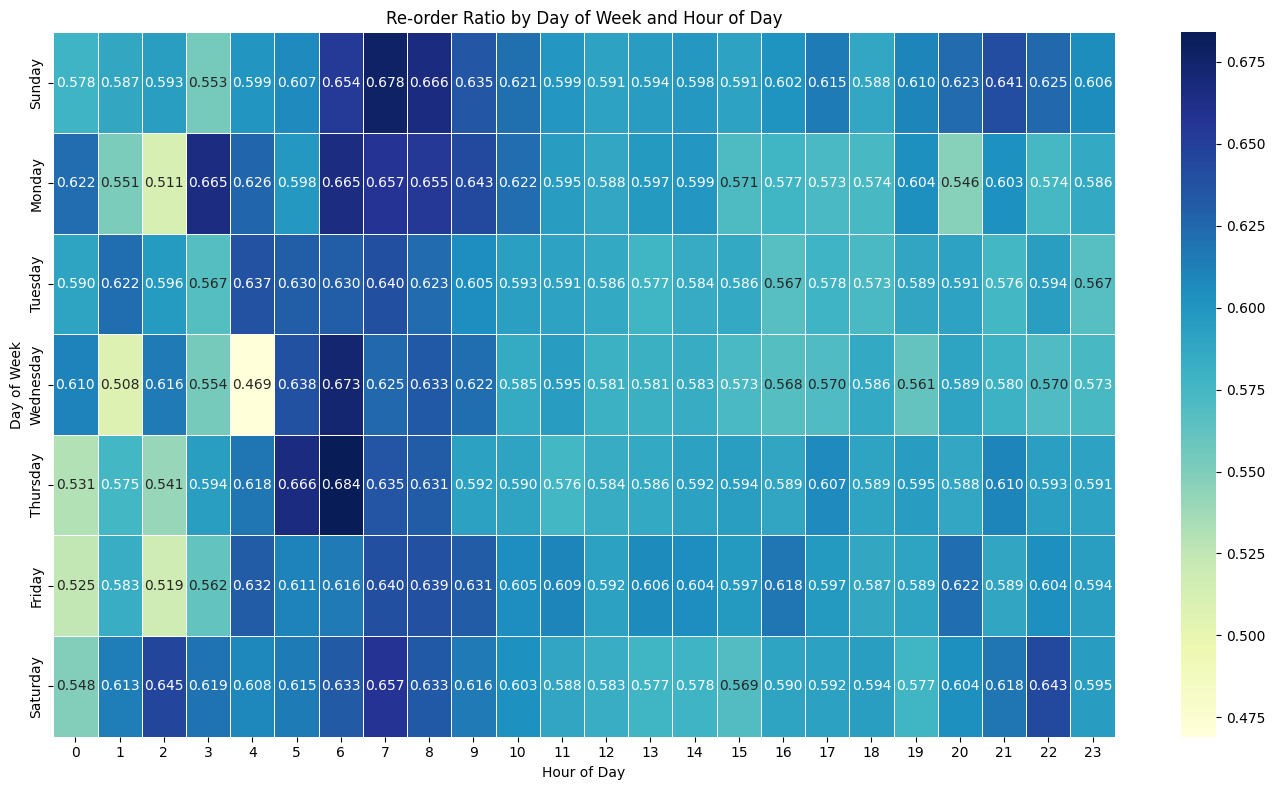

In [22]:
print("\n--- Heatmap of Re-order Ratio by Day of Week and Hour of Day ---")
reorder_heatmap_data = (
    orders_denormalized.groupby(["order_dow", "order_hour_of_day"])["reordered"]
    .mean()
    .unstack()
)
plt.figure(figsize=(14, 8))
sns.heatmap(
    reorder_heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    yticklabels=[
        dow_map[i] for i in sorted(reorder_heatmap_data.index)
    ],  # Use day names for y-axis
)
plt.title("Re-order Ratio by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


## **Stage 2:** Create a basket (4 points)

As the dataset contains huge amount of data, let us take a subset of the data to extract the association rules from it.

**Assumption:** Segment the data by considering the 100 most frequent ordered items. Please note it is just an assumption. You can consider 'n' frequent order items as per your choice.

**Hint:**

- Drop the unwanted columns

- Find the frequencies of orders based on the products and  consider the 100 most frequent order items.

    **Hint:** Count the frequencies of orders for each product_id using `groupby()` and `count()` respectively

- Extract the records of 100 most frequent items (which are extracted in previous step) from combined dataframe.

- Create a Pivot table with `order_id` as index and `product_name` as columns and `reorder` as values.

    - set the `order_id` as index using set_index()
    - fill all the nan values with 0

- After performing the above step, there are a lot of zeros in the data, make sure that any positive values are converted to a 1 and anything less than 0 is set to 0.


In [23]:
# YOUR CODE HERE
top_100_products = product_order_counts.head(100)["product_name"].tolist()
print(
    f"\nTop 100 most frequent ordered products (first 5 shown): {top_100_products[:5]}..."
)



Top 100 most frequent ordered products (first 5 shown): ['Banana', 'Bag of Organic Bananas', 'Organic Strawberries', 'Organic Baby Spinach', 'Large Lemon']...


In [24]:
filtered_orders = orders_denormalized[
    orders_denormalized["product_name"].isin(top_100_products)
]
print(f"\nShape of unfiltered_orders : {orders_denormalized.shape}")
print(f"\n\nShape of filtered_orders (only top 100 products): {filtered_orders.shape}")
print("\n\nFirst 5 rows of filtered_orders:")
filtered_orders.head()



Shape of unfiltered_orders : (1384617, 15)


Shape of filtered_orders (only top 100 products): (314227, 15)


First 5 rows of filtered_orders:


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
3,1,49683,4,0,Cucumber Kirby,83,4,fresh vegetables,produce,112108,train,4,4,10,9.0
5,1,13176,6,0,Bag of Organic Bananas,24,4,fresh fruits,produce,112108,train,4,4,10,9.0
6,1,47209,7,0,Organic Hass Avocado,24,4,fresh fruits,produce,112108,train,4,4,10,9.0
7,1,22035,8,1,Organic Whole String Cheese,21,16,packaged cheese,dairy eggs,112108,train,4,4,10,9.0
9,36,19660,2,1,Spring Water,115,7,water seltzer sparkling water,beverages,79431,train,23,6,18,30.0


In [25]:
basket = (
    filtered_orders.groupby(["order_id", "product_name"])["reordered"]
    .count()
    .unstack(fill_value=0)  # Fill NaN (products not in an order) with 0
)
basket.head(n=5)


product_name,100% Whole Wheat Bread,2% Reduced Fat Milk,Apple Honeycrisp Organic,Asparagus,Bag of Organic Bananas,Banana,Blueberries,Boneless Skinless Chicken Breasts,Broccoli Crown,Bunched Cilantro,...,Sparkling Lemon Water,Sparkling Natural Mineral Water,Sparkling Water Grapefruit,Spring Water,Strawberries,Uncured Genoa Salami,Unsalted Butter,Unsweetened Almondmilk,Unsweetened Original Almond Breeze Almond Milk,Yellow Onions
order_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
38,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [26]:
# another way to create the basket
basket = pd.pivot_table(
    filtered_orders,
    index="order_id",
    columns="product_name",
    values="reordered",
    aggfunc="sum",
    fill_value=0,
)


In [27]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print("\nShape of the created basket:")
print(basket.shape)
print("\nFirst 5 rows of the created basket:")
print(basket.head())


/var/folders/x_/586jm8gs3s385026b8mq6gmc0000gn/T/ipykernel_25373/1008660585.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)



Shape of the created basket:
(94185, 100)

First 5 rows of the created basket:
product_name  100% Whole Wheat Bread  2% Reduced Fat Milk  \
order_id                                                    
1                                  0                    0   
36                                 0                    0   
38                                 0                    0   
96                                 0                    0   
98                                 0                    0   

product_name  Apple Honeycrisp Organic  Asparagus  Bag of Organic Bananas  \
order_id                                                                    
1                                    0          0                       0   
36                                   0          1                       0   
38                                   0          0                       0   
96                                   0          0                       0   
98                            

In [28]:
basket.head(n=5)


product_name,100% Whole Wheat Bread,2% Reduced Fat Milk,Apple Honeycrisp Organic,Asparagus,Bag of Organic Bananas,Banana,Blueberries,Boneless Skinless Chicken Breasts,Broccoli Crown,Bunched Cilantro,...,Sparkling Lemon Water,Sparkling Natural Mineral Water,Sparkling Water Grapefruit,Spring Water,Strawberries,Uncured Genoa Salami,Unsalted Butter,Unsweetened Almondmilk,Unsweetened Original Almond Breeze Almond Milk,Yellow Onions
order_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
38,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## **Stage 3:** Apply Apriori algorithm (2 points)

- As the dataset contains huge amount of data, let us take a subset of the data to extract the association rules from it.

  **Assumption:** Segment the basket by considering 100000 records. Please note its just an assumption, you can consider 'n'  records as per your choice.

  **Hint:** [apriori](http://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/)

- Find the association rules and make a dataframe

In [29]:
# YOUR CODE HERE
num_records_for_apriori = min(100000, basket.shape[0])
basket_subset = basket.head(num_records_for_apriori)
print(
    f"\nUsing a subset of the basket with {num_records_for_apriori} records for Apriori."
)



Using a subset of the basket with 94185 records for Apriori.


In [30]:
frequent_itemsets = apriori(basket_subset, min_support=0.01, use_colnames=True)
print("\nFrequent Itemsets (first 5 sorted by support):")
print(frequent_itemsets.sort_values(by="support", ascending=False).head())


/Users/rajiv-ranjan/Documents/github/rajiv-ranjan/cds-mini-projects/m8/mp1/.venv/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(



Frequent Itemsets (first 5 sorted by support):
     support                  itemsets
5   0.175792                  (Banana)
4   0.141870  (Bag of Organic Bananas)
66  0.091342    (Organic Strawberries)
34  0.085523    (Organic Baby Spinach)
31  0.066104         (Organic Avocado)


In [31]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
print("\nAssociation Rules (first 5 sorted by lift):")
print(rules.sort_values(by="lift", ascending=False).head())



Association Rules (first 5 sorted by lift):
               antecedents             consequents  antecedent support  \
19                 (Limes)           (Large Lemon)            0.044954   
18           (Large Lemon)                 (Limes)            0.062887   
30   (Organic Raspberries)  (Organic Strawberries)            0.045432   
31  (Organic Strawberries)   (Organic Raspberries)            0.091342   
21       (Organic Avocado)           (Large Lemon)            0.066104   

    consequent support   support  confidence      lift  representativity  \
19            0.062887  0.010288    0.228862  3.639259               1.0   
18            0.044954  0.010288    0.163600  3.639259               1.0   
30            0.091342  0.013028    0.286749  3.139309               1.0   
31            0.045432  0.013028    0.142625  3.139309               1.0   
21            0.062887  0.010256    0.155156  2.467221               1.0   

    leverage  conviction  zhangs_metric   jaccard  ce

In [32]:
print("\nTop 10 Association Rules by Confidence:")
print(rules.sort_values(by="confidence", ascending=False).head(10))



Top 10 Association Rules by Confidence:
               antecedents               consequents  antecedent support  \
3   (Organic Hass Avocado)  (Bag of Organic Bananas)            0.064150   
4    (Organic Raspberries)  (Bag of Organic Bananas)            0.045432   
17          (Strawberries)                  (Banana)            0.050815   
10       (Organic Avocado)                  (Banana)            0.066104   
30   (Organic Raspberries)    (Organic Strawberries)            0.045432   
7   (Organic Strawberries)  (Bag of Organic Bananas)            0.091342   
8            (Large Lemon)                  (Banana)            0.062887   
19                 (Limes)             (Large Lemon)            0.044954   
1   (Organic Baby Spinach)  (Bag of Organic Bananas)            0.085523   
29  (Organic Hass Avocado)    (Organic Strawberries)            0.064150   

    consequent support   support  confidence      lift  representativity  \
3             0.141870  0.021373    0.333168  

In [33]:
print("\nTop 10 Association Rules by Lift (excluding rules with lift of 1, if any):")
print(rules[rules["lift"] > 1].sort_values(by="lift", ascending=False).head(10))



Top 10 Association Rules by Lift (excluding rules with lift of 1, if any):
                 antecedents               consequents  antecedent support  \
19                   (Limes)             (Large Lemon)            0.044954   
18             (Large Lemon)                   (Limes)            0.062887   
30     (Organic Raspberries)    (Organic Strawberries)            0.045432   
31    (Organic Strawberries)     (Organic Raspberries)            0.091342   
21         (Organic Avocado)             (Large Lemon)            0.066104   
20             (Large Lemon)         (Organic Avocado)            0.062887   
3     (Organic Hass Avocado)  (Bag of Organic Bananas)            0.064150   
2   (Bag of Organic Bananas)    (Organic Hass Avocado)            0.141870   
5   (Bag of Organic Bananas)     (Organic Raspberries)            0.141870   
4      (Organic Raspberries)  (Bag of Organic Bananas)            0.045432   

    consequent support   support  confidence      lift  represent

The `return_metrics` parameter in the `association_rules` function allows you to specify which metrics you want to include in the output DataFrame. Each of these metrics provides a different insight into the strength and interestingness of an association rule.

Here's an explanation of the metrics listed in the `return_metrics` default list:

* **`antecedent support`**: This is the support of the antecedent (left-hand side) of the rule. It indicates how frequently the item(s) in the antecedent appear in the dataset.
* **`consequent support`**: This is the support of the consequent (right-hand side) of the rule. It indicates how frequently the item(s) in the consequent appear in the dataset.
* **`support`**: This is the support of the entire rule, meaning the support of the union of the antecedent and the consequent. It indicates how frequently the antecedent and consequent appear together in the transactions.
    * Formula: $Support(A \Rightarrow B) = P(A \cap B)$
* **`confidence`**: This indicates how often the consequent is true when the antecedent is true. It measures the reliability of the rule.
    * Formula: $Confidence(A \Rightarrow B) = P(B|A) = \frac{P(A \cap B)}{P(A)}$
* **`lift`**: This measures how much more likely the consequent is given the antecedent, relative to its prior probability. A lift value greater than 1 indicates a positive correlation between the antecedent and consequent, less than 1 indicates a negative correlation, and equal to 1 indicates independence.
    * Formula: $Lift(A \Rightarrow B) = \frac{P(A \cap B)}{P(A)P(B)} = \frac{Confidence(A \Rightarrow B)}{P(B)}$
* **`representativity`**: This metric is specific to the `mlxtend` library and relates to how "representative" a rule is of the underlying data distribution, often reflecting how often the rule applies.
* **`leverage`**: This measures the difference between the observed frequency of A and B appearing together and what would be expected if A and B were independent. A leverage of 0 means independence.
    * Formula: $Leverage(A \Rightarrow B) = P(A \cap B) - P(A)P(B)$
* **`conviction`**: This measures the dependency of the consequent on the antecedent. A high conviction value indicates that the consequent is highly dependent on the antecedent.
    * Formula: $Conviction(A \Rightarrow B) = \frac{P(A)P(\neg B)}{P(A \cap \neg B)} = \frac{1 - Support(B)}{1 - Confidence(A \Rightarrow B)}$
* **`zhangs_metric`**: This is a more robust measure of association between items, often used to overcome some limitations of lift and conviction, especially when dealing with rare items. It ranges from -1 to 1.
* **`jaccard`**: This measures the similarity between the itemsets in the antecedent and consequent.
    * Formula: $Jaccard(A, B) = \frac{P(A \cap B)}{P(A \cup B)}$
* **`certainty`**: This metric is equivalent to confidence.
* **`kulczynski`**: This is another measure of association, useful for cases where confidence might be misleading due to low support of the antecedent.

You can select a subset of these metrics to be returned in the `association_rules` output by passing a list of desired metric names to the `return_metrics` parameter.